In [1]:
import os

import numpy as np
import pandas as pd
def read_file(file_path_url):
  return np.loadtxt(file_path_url,delimiter="\t")

# fordA_test.csv, fordA_train.csv 가 없으면 다운로드
if not (os.path.isfile("fordA_test.csv") and os.path.isfile("fordA_train.csv")):
  root_url = "https://raw.githubusercontent.com/hfawaz/cd-diagram/master/FordA/"

  # write csv file
  pd.DataFrame(read_file(root_url + "FordA_TRAIN.tsv")).to_csv("fordA_train.csv", index=False)
  pd.DataFrame(read_file(root_url + "FordA_TEST.tsv")).to_csv("fordA_test.csv", index=False)

train = pd.read_csv("./fordA_train.csv")
test = pd.read_csv("./fordA_test.csv")

In [2]:
df = pd.DataFrame(train)
x_train_temp = df.iloc[:,1:] # 500개의 데이터
y_train_temp = df.iloc[:,0] # 정답 데이터
df

,0,1,2,3,4,5,6,7,8,9,...,491,492,493,494,495,496,497,498,499,500
0,-1.0,-0.797172,-0.664392,-0.373015,0.040815,0.526936,0.984288,1.353120,1.578108,1.659251,...,1.120756,0.722417,0.362068,0.092083,-0.081268,-0.212573,-0.391456,-0.664392,-1.073796,-1.564343
1,1.0,0.804855,0.634629,0.373474,0.038343,-0.340988,-0.740860,-1.109667,-1.395357,-1.570192,...,0.386403,0.049213,-0.258138,-0.510583,-0.683647,-0.773817,-0.785255,-0.714885,-0.560443,-0.319086
2,-1.0,0.727985,0.111284,-0.499124,-1.068629,-1.578351,-1.990534,-2.302031,-2.503403,-2.585211,...,0.394463,0.463685,0.507735,0.517174,0.504588,0.476270,0.438513,0.394463,0.339400,0.255391
3,-1.0,-0.234439,-0.502157,-0.732488,-0.946128,-1.139739,-1.323336,-1.490243,-1.607077,-1.620430,...,-0.952804,-0.929437,-0.922761,-0.929437,-0.909409,-0.835970,-0.695768,-0.478790,-0.188707,0.119736
4,-1.0,-0.171328,-0.062285,0.235829,0.710396,1.239969,1.649823,1.876321,1.865535,1.703751,...,0.776188,0.725496,0.697453,0.731967,0.808545,0.839823,0.733046,0.437520,-0.026585,-0.602213
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3596,-1.0,0.196022,-0.070102,-0.336226,-0.516799,-0.555282,-0.442793,-0.221369,0.025217,0.233320,...,1.715205,1.129082,0.528158,-0.039020,-0.573043,-1.061479,-1.514392,-1.934743,-2.316612,-2.603753
3597,1.0,0.041994,0.422255,0.740529,0.975426,1.109891,1.137270,1.058349,0.894955,0.671224,...,-0.463329,-0.392667,-0.333749,-0.316543,-0.340299,-0.392876,-0.450805,-0.482609,-0.467769,-0.393755
3598,-1.0,-0.570054,-0.333165,-0.293519,-0.425344,-0.590869,-0.615648,-0.348033,0.275412,1.153586,...,0.902821,0.579700,0.157463,-0.353980,-0.885246,-1.314421,-1.512655,-1.393714,-0.942733,-0.270722
3599,1.0,2.006732,2.079150,2.022036,1.867560,1.648112,1.379446,1.093717,0.784057,0.434150,...,1.268671,1.148971,0.928088,0.634953,0.311682,-0.007376,-0.270543,-0.432145,-0.441231,-0.280709


In [4]:
import matplotlib.pyplot as plt
normal_x = x_train_temp[y_train_temp == 1] # 정상 데이터만
abnormal_x = x_train_temp[y_train_temp == -1] # 비정상 데이터만

normal_x = normal_x.reset_index(drop=True)


In [5]:
#정규화 Robust Scaler
from sklearn.preprocessing import StandardScaler
all_x = pd.concat([normal_x, abnormal_x])
all_y = pd.concat([y_train_temp[y_train_temp == 1], y_train_temp[y_train_temp == -1]])
print(all_y)
scaler = StandardScaler()
all_x_scaled = scaler.fit_transform(all_x.T).T

print("Scaled data shape:", all_x_scaled.shape)

1       1.0
5       1.0
6       1.0
7       1.0
8       1.0
       ... 
3591   -1.0
3592   -1.0
3596   -1.0
3598   -1.0
3600   -1.0
Name: 0, Length: 3601, dtype: float64
Scaled data shape: (3601, 500)


In [17]:
# 차원 수
from numpy.linalg import svd

k = 3
U_scaled, S_scaled, Vt_scaled = svd(all_x_scaled, full_matrices=False)
U_3d_scaled = U_scaled[:, :k]
# 3차원 latent 좌표(시각화용)
Z_3d = U_scaled[:, :k] * S_scaled[:k]
# 3차원 성분만 남긴 복원 데이터(denoised reconstruction)
X_3d_recon = Z_3d @ Vt_scaled[:k, :]
X_k = U_scaled[:,:k] @ np.diag(S_scaled[:k]) @ Vt_scaled[:k,:]

print(X_3d_recon.shape)
# 2. 누적 설명 분산 비율 시각화 (Cumulative Explained Variance Ratio)
explained_variance_ratio = (S_scaled**2) / np.sum(S_scaled**2)
cumulative_variance = np.cumsum(explained_variance_ratio)

(3601, 500)


In [19]:

from numpy.linalg import svd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import robust_scale, StandardScaler

x_test = test.iloc[:, 1:]
y_test = test.iloc[:, 0]
x_test_scaled = StandardScaler().fit_transform(x_test)

U_scaled, S_scaled, Vt_scaled = svd(all_x_scaled, full_matrices=False)
# 0. 누적 설명 분산 비율 시각화 (Cumulative Explained Variance Ratio)
explained_variance_ratio = (S_scaled**2) / np.sum(S_scaled**2)
cumulative_variance = np.cumsum(explained_variance_ratio)

# 1. 90% 설명력을 확보하는 성분 개수 설정 (이전 셀 결과 기반)
n_components_90 = np.where(cumulative_variance >= 0.9)[0][0] + 1
print(f"사용할 주성분 개수: {n_components_90}")

# 2. 학습 데이터에서 상위 n개 주성분 좌표(score) 추출
# U_scaled는 샘플-축 방향 성분이고, 실제 좌표는 U_scaled * S_scaled 로 계산한다.
X_train_pca_multi = U_scaled[:, :n_components_90] * S_scaled[:n_components_90]

# 3. 테스트 데이터 PCA 투영
# 학습 데이터에서 얻은 주성분 축(Vt_scaled)에 테스트 데이터를 사영한다.
X_test_pca_multi = np.dot(x_test_scaled, Vt_scaled[:n_components_90].T)


사용할 주성분 개수: 47


SVM (RBF) Test Accuracy: 87.80%

Classification Report:
              precision    recall  f1-score   support

        -1.0       0.88      0.88      0.88       681
         1.0       0.87      0.87      0.87       639

    accuracy                           0.88      1320
   macro avg       0.88      0.88      0.88      1320
weighted avg       0.88      0.88      0.88      1320



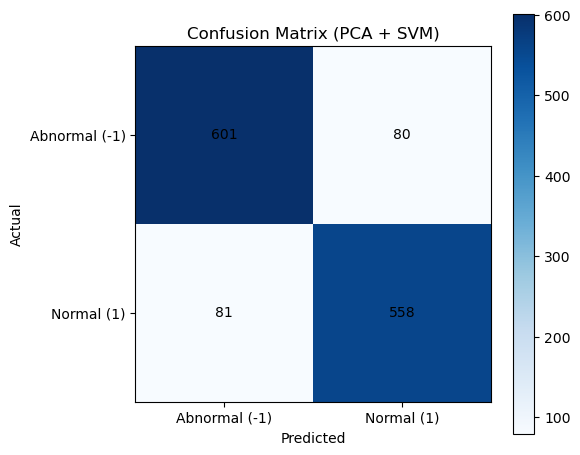

In [11]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

# SVM 학습 (RBF kernel)
svm_clf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_clf.fit(X_train_pca_multi, all_y)

# 예측 및 평가
y_pred_svm = svm_clf.predict(X_test_pca_multi)
svm_acc = accuracy_score(y_test, y_pred_svm)

print(f"SVM (RBF) Test Accuracy: {svm_acc*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

# 혼동 행렬 시각화
cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(6, 5))
plt.imshow(cm_svm, cmap='Blues')
plt.title('Confusion Matrix (PCA + SVM)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks([0, 1], ['Abnormal (-1)', 'Normal (1)'])
plt.yticks([0, 1], ['Abnormal (-1)', 'Normal (1)'])

for i in range(cm_svm.shape[0]):
    for j in range(cm_svm.shape[1]):
        plt.text(j, i, cm_svm[i, j], ha='center', va='center', color='black')

plt.colorbar()
plt.tight_layout()
plt.show()

In [12]:
import pandas as pd
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

kernel_results = []

for kernel_name in ['linear', 'rbf', 'poly', 'sigmoid']:
    clf = SVC(kernel=kernel_name, C=1.0, gamma='scale', random_state=42)
    clf.fit(X_train_pca_multi, all_y)
    pred = clf.predict(X_test_pca_multi)
    acc = accuracy_score(y_test, pred)
    kernel_results.append({'kernel': kernel_name, 'accuracy': acc})
    print(f"Kernel: {kernel_name:7s} | Test Accuracy: {acc*100:.2f}%")

kernel_results_df = pd.DataFrame(kernel_results).sort_values('accuracy', ascending=False).reset_index(drop=True)
print("\nKernel comparison summary:")
display(kernel_results_df)

Kernel: linear  | Test Accuracy: 50.30%
Kernel: rbf     | Test Accuracy: 87.80%
Kernel: poly    | Test Accuracy: 52.65%
Kernel: sigmoid | Test Accuracy: 52.12%

Kernel comparison summary:


,kernel,accuracy
0,rbf,0.878030
1,poly,0.526515
2,sigmoid,0.521212
3,linear,0.503030


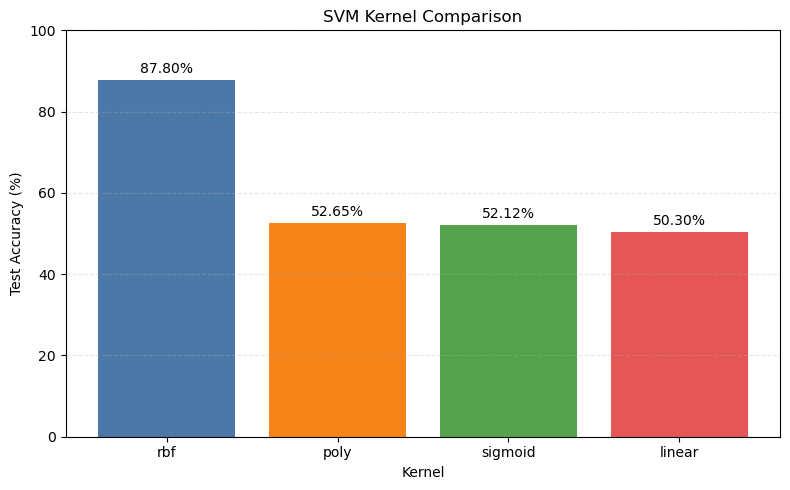

In [20]:
import matplotlib.pyplot as plt

plot_df = kernel_results_df.copy()
plot_df['accuracy_pct'] = plot_df['accuracy'] * 100

plt.figure(figsize=(8, 5))
bars = plt.bar(plot_df['kernel'], plot_df['accuracy_pct'], color=['#4C78A8', '#F58518', '#54A24B', '#E45756'])
plt.title('SVM Kernel Comparison')
plt.xlabel('Kernel')
plt.ylabel('Test Accuracy (%)')
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.3)

for bar, value in zip(bars, plot_df['accuracy_pct']):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f'{value:.2f}%',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

In [13]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 0.001, 0.01, 0.1]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
svm_grid = GridSearchCV(
    estimator=SVC(kernel='rbf', random_state=42),
    param_grid=param_grid,
    scoring='accuracy',
    cv=cv,
    n_jobs=-1
 )

svm_grid.fit(X_train_pca_multi, all_y)

best_svm = svm_grid.best_estimator_
y_pred_svm_tuned = best_svm.predict(X_test_pca_multi)
svm_tuned_acc = accuracy_score(y_test, y_pred_svm_tuned)

print("Best parameters:", svm_grid.best_params_)
print(f"Best CV Accuracy: {svm_grid.best_score_*100:.2f}%")
print(f"Tuned RBF SVM Test Accuracy: {svm_tuned_acc*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm_tuned))

Best parameters: {'C': 1, 'gamma': 'scale'}
Best CV Accuracy: 86.84%
Tuned RBF SVM Test Accuracy: 87.80%

Classification Report:
              precision    recall  f1-score   support

        -1.0       0.88      0.88      0.88       681
         1.0       0.87      0.87      0.87       639

    accuracy                           0.88      1320
   macro avg       0.88      0.88      0.88      1320
weighted avg       0.88      0.88      0.88      1320



CV accuracy matrix (rows=n_components, cols=SVM params):


,"C=0.1, g=scale","C=0.1, g=0.001","C=0.1, g=0.01","C=0.1, g=0.1","C=1, g=scale","C=1, g=0.001","C=1, g=0.01","C=1, g=0.1","C=10, g=scale","C=10, g=0.001","C=10, g=0.01","C=10, g=0.1","C=100, g=scale","C=100, g=0.001","C=100, g=0.01","C=100, g=0.1"
5,0.6812,0.6257,0.6865,0.5126,0.6943,0.6698,0.6879,0.6520,0.6823,0.6756,0.6712,0.6270,0.6654,0.6926,0.6387,0.6265
10,0.7037,0.6612,0.7159,0.5126,0.7342,0.6995,0.7329,0.5412,0.7187,0.7148,0.6904,0.5660,0.6843,0.7192,0.6668,0.5660
20,0.7237,0.6579,0.6531,0.5126,0.7490,0.7376,0.7531,0.5126,0.7245,0.7362,0.7501,0.5126,0.7134,0.7106,0.7501,0.5126
30,0.7778,0.7087,0.5126,0.5126,0.8067,0.8017,0.8020,0.5126,0.7798,0.8056,0.8067,0.5126,0.7740,0.7703,0.8067,0.5126
40,0.8173,0.7512,0.5126,0.5126,0.8426,0.8412,0.8342,0.5126,0.8353,0.8362,0.8387,0.5126,0.8339,0.8162,0.8387,0.5126
50,0.8314,0.7328,0.5126,0.5126,0.8698,0.8673,0.8598,0.5126,0.8634,0.8720,0.8642,0.5126,0.8628,0.8617,0.8642,0.5126
70,0.7615,0.6784,0.5126,0.5126,0.8462,0.8325,0.7742,0.5126,0.8501,0.8503,0.7784,0.5126,0.8489,0.8456,0.7784,0.5126
100,0.7278,0.6629,0.5126,0.5126,0.8123,0.7817,0.7337,0.5126,0.8176,0.8151,0.7306,0.5126,0.8178,0.8037,0.7306,0.5126
150,0.7278,0.6634,0.5126,0.5126,0.8131,0.7831,0.7340,0.5126,0.8173,0.8145,0.7317,0.5126,0.8164,0.8012,0.7317,0.5126


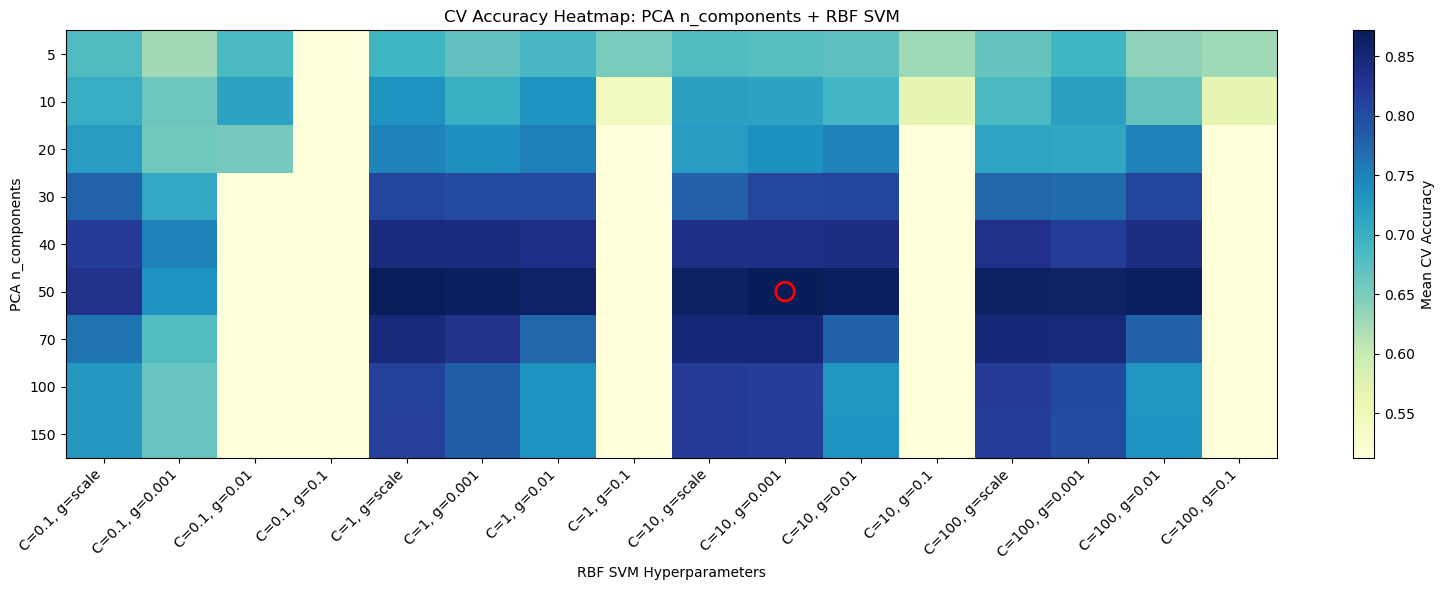


Best joint configuration:
{'n_components': 50, 'C': 10, 'gamma': 0.001, 'cv_accuracy': 0.8719864385883802}
Test Accuracy with best joint config: 88.48%

Classification Report:
              precision    recall  f1-score   support

        -1.0       0.87      0.91      0.89       681
         1.0       0.90      0.86      0.88       639

    accuracy                           0.88      1320
   macro avg       0.89      0.88      0.88      1320
weighted avg       0.89      0.88      0.88      1320



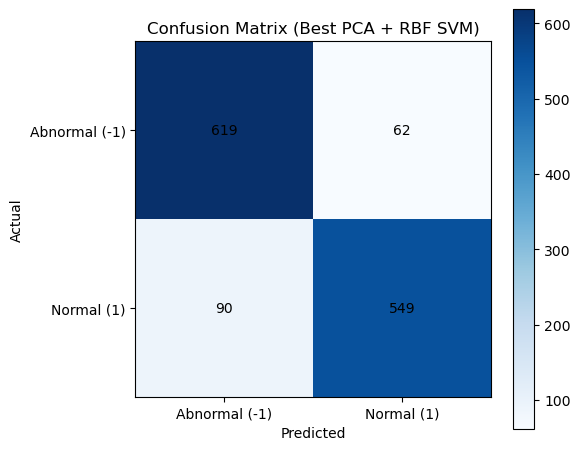

In [21]:
from itertools import product
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 탐색할 PCA 차원 수와 SVM 하이퍼파라미터
n_components_grid = [5, 10, 20, 30, 40, 50, 70, 100, 150]
C_grid = [0.1, 1, 10, 100]
gamma_grid = ['scale', 0.001, 0.01, 0.1]
param_pairs = list(product(C_grid, gamma_grid))
param_labels = [f"C={c}, g={g}" for c, g in param_pairs]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
score_matrix = np.zeros((len(n_components_grid), len(param_pairs)))
best_result = {
    'n_components': None,
    'C': None,
    'gamma': None,
    'cv_accuracy': -np.inf
}

for row_idx, n_comp in enumerate(n_components_grid):
    X_train_n = np.dot(all_x_scaled, Vt_scaled[:n_comp].T)

    for col_idx, (c_value, gamma_value) in enumerate(param_pairs):
        svm_model = SVC(kernel='rbf', C=c_value, gamma=gamma_value, random_state=42)
        cv_scores = cross_val_score(svm_model, X_train_n, all_y, cv=cv, scoring='accuracy', n_jobs=-1)
        mean_score = cv_scores.mean()
        score_matrix[row_idx, col_idx] = mean_score

        if mean_score > best_result['cv_accuracy']:
            best_result = {
                'n_components': n_comp,
                'C': c_value,
                'gamma': gamma_value,
                'cv_accuracy': mean_score
            }

score_df = pd.DataFrame(score_matrix, index=n_components_grid, columns=param_labels)
print('CV accuracy matrix (rows=n_components, cols=SVM params):')
display(score_df.round(4))

plt.figure(figsize=(16, 6))
plt.imshow(score_matrix, aspect='auto', cmap='YlGnBu')
plt.colorbar(label='Mean CV Accuracy')
plt.xticks(range(len(param_labels)), param_labels, rotation=45, ha='right')
plt.yticks(range(len(n_components_grid)), n_components_grid)
plt.xlabel('RBF SVM Hyperparameters')
plt.ylabel('PCA n_components')
plt.title('CV Accuracy Heatmap: PCA n_components + RBF SVM')

best_row = n_components_grid.index(best_result['n_components'])
best_col = param_pairs.index((best_result['C'], best_result['gamma']))
plt.scatter(best_col, best_row, s=180, facecolors='none', edgecolors='red', linewidths=2)
plt.tight_layout()
plt.show()

# 전체 최적 조합으로 학습 후 테스트셋 평가
best_n = best_result['n_components']
X_train_best = np.dot(all_x_scaled, Vt_scaled[:best_n].T)
X_test_best = np.dot(x_test_scaled, Vt_scaled[:best_n].T)

best_joint_svm = SVC(
    kernel='rbf',
    C=best_result['C'],
    gamma=best_result['gamma'],
    random_state=42
)
best_joint_svm.fit(X_train_best, all_y)
y_pred_joint = best_joint_svm.predict(X_test_best)
joint_test_acc = accuracy_score(y_test, y_pred_joint)

print('\nBest joint configuration:')
print(best_result)
print(f"Test Accuracy with best joint config: {joint_test_acc*100:.2f}%")
print('\nClassification Report:')
print(classification_report(y_test, y_pred_joint))

cm_joint = confusion_matrix(y_test, y_pred_joint)
plt.figure(figsize=(6, 5))
plt.imshow(cm_joint, cmap='Blues')
plt.title('Confusion Matrix (Best PCA + RBF SVM)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks([0, 1], ['Abnormal (-1)', 'Normal (1)'])
plt.yticks([0, 1], ['Abnormal (-1)', 'Normal (1)'])

for i in range(cm_joint.shape[0]):
    for j in range(cm_joint.shape[1]):
        plt.text(j, i, cm_joint[i, j], ha='center', va='center', color='black')

plt.colorbar()
plt.tight_layout()
plt.show()

## Patch Transformer 기반 FordA 분류
기존 SVD/PCA + SVM 실험은 시계열을 하나의 정적 벡터로 변환한 뒤 분류했다. 이번 실험에서는 500개 타임스텝을 일정 길이의 패치로 나누고, 각 패치를 임베딩한 뒤 Transformer Encoder가 패치 간 관계를 학습하도록 구성한다.

구조는 다음과 같다.

`Input Time Series -> Patch Split -> Conv1d Patch Embedding -> CLS Token + Positional Embedding -> Transformer Encoder -> Binary Classifier`

이 모델은 1D-CNN처럼 국소적인 파형 패턴을 패치 단위로 포착하면서, Multi-Head Attention을 통해 멀리 떨어진 패치 간의 전역적 관계도 함께 학습한다.

In [25]:
import random
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

# SVM 실험에서 사용한 scaled train/test 데이터를 그대로 사용한다.
# label은 -1 -> 0, 1 -> 1 로 변환한다.
X_deep = all_x_scaled.astype(np.float32)
y_deep = (all_y.to_numpy() == 1).astype(np.int64)
X_test_deep = x_test_scaled.astype(np.float32)
y_test_deep = (y_test.to_numpy() == 1).astype(np.int64)

X_train_deep, X_val_deep, y_train_deep, y_val_deep = train_test_split(
    X_deep,
    y_deep,
    test_size=0.2,
    random_state=seed,
    stratify=y_deep
)

def make_loader(X, y, batch_size=64, shuffle=False):
    X_tensor = torch.tensor(X).unsqueeze(1)  # (batch, channel=1, time=500)
    y_tensor = torch.tensor(y)
    dataset = TensorDataset(X_tensor, y_tensor)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(X_train_deep, y_train_deep, batch_size=64, shuffle=True)
val_loader = make_loader(X_val_deep, y_val_deep, batch_size=128, shuffle=False)
test_loader = make_loader(X_test_deep, y_test_deep, batch_size=128, shuffle=False)

print('Train shape:', X_train_deep.shape)
print('Validation shape:', X_val_deep.shape)
print('Test shape:', X_test_deep.shape)

Device: cuda
Train shape: (2880, 500)
Validation shape: (721, 500)
Test shape: (1320, 500)


In [26]:
class PatchTransformerClassifier(nn.Module):
    def __init__(
        self,
        seq_len=500,
        patch_len=50,
        stride=25,
        embed_dim=64,
        num_heads=4,
        num_layers=2,
        ff_dim=128,
        dropout=0.1,
        num_classes=2,
    ):
        super().__init__()
        self.patch_len = patch_len
        self.stride = stride
        self.patch_embed = nn.Conv1d(
            in_channels=1,
            out_channels=embed_dim,
            kernel_size=patch_len,
            stride=stride,
        )

        num_patches = ((seq_len - patch_len) // stride) + 1
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=ff_dim,
            dropout=dropout,
            batch_first=True,
            activation='gelu',
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(embed_dim)
        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        x = self.patch_embed(x)          # (batch, embed_dim, num_patches)
        x = x.transpose(1, 2)            # (batch, num_patches, embed_dim)

        batch_size = x.size(0)
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        x = torch.cat([cls_tokens, x], dim=1)
        x = x + self.pos_embed[:, :x.size(1), :]

        x = self.encoder(x)
        cls_output = self.norm(x[:, 0])
        return self.classifier(cls_output)

patch_model = PatchTransformerClassifier(
    seq_len=X_deep.shape[1],
    patch_len=50,
    stride=25,
    embed_dim=64,
    num_heads=4,
    num_layers=2,
    ff_dim=128,
    dropout=0.1,
    num_classes=2,
 ).to(device)

total_params = sum(p.numel() for p in patch_model.parameters() if p.requires_grad)
print(patch_model)
print(f'Trainable parameters: {total_params:,}')

PatchTransformerClassifier(
  (patch_embed): Conv1d(1, 64, kernel_size=(50,), stride=(25,))
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (classifier): Linear(in_features=64, out_features=2, bias=True)
)
Trainable parameters: 71,810


Epoch 01 | Train Loss: 0.6069 | Val Loss: 0.3916 | Val Acc: 85.02% *
Epoch 02 | Train Loss: 0.2790 | Val Loss: 0.2807 | Val Acc: 88.77% *
Epoch 03 | Train Loss: 0.2042 | Val Loss: 0.2354 | Val Acc: 91.26% *
Epoch 05 | Train Loss: 0.1691 | Val Loss: 0.2377 | Val Acc: 90.57% 
Epoch 07 | Train Loss: 0.1407 | Val Loss: 0.2392 | Val Acc: 91.40% *
Epoch 10 | Train Loss: 0.1337 | Val Loss: 0.2493 | Val Acc: 91.12% 
Epoch 12 | Train Loss: 0.1305 | Val Loss: 0.2190 | Val Acc: 92.09% *
Epoch 15 | Train Loss: 0.1158 | Val Loss: 0.2593 | Val Acc: 90.98% 
Epoch 16 | Train Loss: 0.1132 | Val Loss: 0.2385 | Val Acc: 92.37% *
Epoch 20 | Train Loss: 0.0829 | Val Loss: 0.3149 | Val Acc: 91.12% 
Epoch 25 | Train Loss: 0.0784 | Val Loss: 0.2801 | Val Acc: 91.96% 

Early stopping at epoch 26. Best epoch: 16

Best Validation Accuracy: 92.37%
Best Epoch: 16
Patch Transformer Test Accuracy: 93.56%

Classification Report:
               precision    recall  f1-score   support

Abnormal (-1)       0.95      0.9

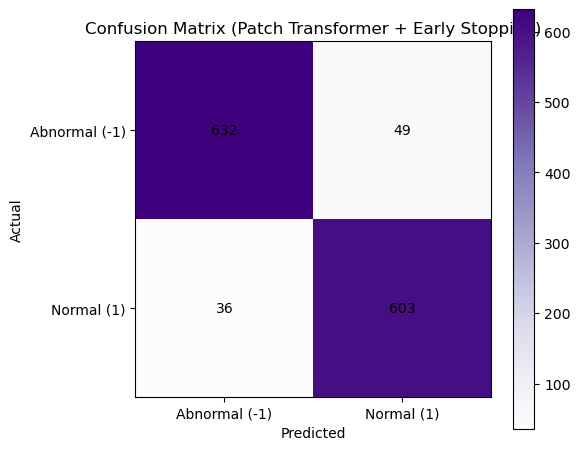

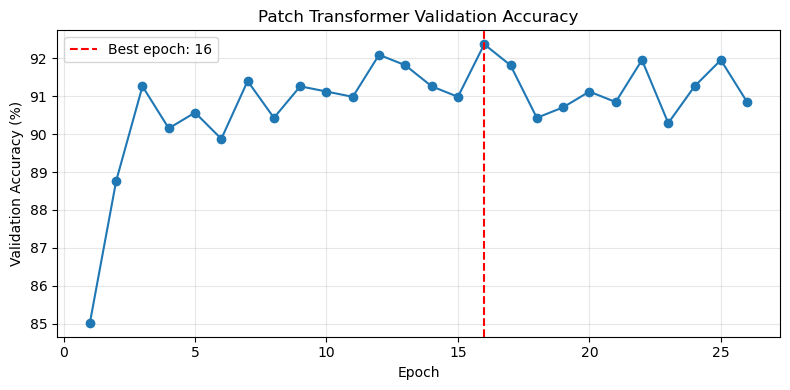

In [27]:
def evaluate_torch_model(model, loader):
    model.eval()
    all_preds = []
    all_targets = []
    total_loss = 0.0
    criterion = nn.CrossEntropyLoss()

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            total_loss += loss.item() * X_batch.size(0)
            preds = logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(y_batch.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    accuracy = accuracy_score(all_targets, all_preds)
    return avg_loss, accuracy, np.array(all_targets), np.array(all_preds)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(patch_model.parameters(), lr=1e-3, weight_decay=1e-4)

epochs = 80
patience = 10
min_delta = 0.0005
best_val_acc = 0.0
best_epoch = 0
best_state = None
epochs_without_improvement = 0
history = []

for epoch in range(1, epochs + 1):
    patch_model.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits = patch_model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * X_batch.size(0)

    train_loss /= len(train_loader.dataset)
    val_loss, val_acc, _, _ = evaluate_torch_model(patch_model, val_loader)
    history.append({'epoch': epoch, 'train_loss': train_loss, 'val_loss': val_loss, 'val_accuracy': val_acc})

    if val_acc > best_val_acc + min_delta:
        best_val_acc = val_acc
        best_epoch = epoch
        best_state = {key: value.cpu().clone() for key, value in patch_model.state_dict().items()}
        epochs_without_improvement = 0
        improved = '*'
    else:
        epochs_without_improvement += 1
        improved = ''

    if epoch == 1 or epoch % 5 == 0 or improved:
        print(
            f'Epoch {epoch:02d} | '
            f'Train Loss: {train_loss:.4f} | '
            f'Val Loss: {val_loss:.4f} | '
            f'Val Acc: {val_acc*100:.2f}% {improved}'
        )

    if epochs_without_improvement >= patience:
        print(f'\nEarly stopping at epoch {epoch}. Best epoch: {best_epoch}')
        break

patch_model.load_state_dict(best_state)
test_loss, patch_test_acc, y_true_patch, y_pred_patch = evaluate_torch_model(patch_model, test_loader)

print(f'\nBest Validation Accuracy: {best_val_acc*100:.2f}%')
print(f'Best Epoch: {best_epoch}')
print(f'Patch Transformer Test Accuracy: {patch_test_acc*100:.2f}%')
print('\nClassification Report:')
print(classification_report(y_true_patch, y_pred_patch, target_names=['Abnormal (-1)', 'Normal (1)']))

cm_patch = confusion_matrix(y_true_patch, y_pred_patch)
plt.figure(figsize=(6, 5))
plt.imshow(cm_patch, cmap='Purples')
plt.title('Confusion Matrix (Patch Transformer + Early Stopping)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks([0, 1], ['Abnormal (-1)', 'Normal (1)'])
plt.yticks([0, 1], ['Abnormal (-1)', 'Normal (1)'])

for i in range(cm_patch.shape[0]):
    for j in range(cm_patch.shape[1]):
        plt.text(j, i, cm_patch[i, j], ha='center', va='center', color='black')

plt.colorbar()
plt.tight_layout()
plt.show()

history_df = pd.DataFrame(history)
plt.figure(figsize=(8, 4))
plt.plot(history_df['epoch'], history_df['val_accuracy'] * 100, marker='o')
plt.axvline(best_epoch, color='red', linestyle='--', label=f'Best epoch: {best_epoch}')
plt.title('Patch Transformer Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy (%)')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Patch Length / Stride 튜닝
epoch를 늘렸을 때 성능이 더 올라가지 않았으므로, 이번에는 패치 구성 자체를 바꿔본다. `patch_len`은 한 패치가 보는 시간 구간의 길이이고, `stride`는 다음 패치로 이동하는 간격이다.

- 작은 `patch_len`: 더 짧고 세밀한 국소 패턴을 본다.
- 큰 `patch_len`: 더 긴 파형 문맥을 한 번에 본다.
- 작은 `stride`: 패치가 많이 겹쳐 정보 손실이 줄지만 계산량이 증가한다.
- 큰 `stride`: 계산은 가벼워지지만 패치 경계의 정보가 끊길 수 있다.

Running patch_len=25, stride=25...
  patches=20 | best_epoch= 7 | val=92.51% | test=91.97%
Running patch_len=32, stride=16...
  patches=30 | best_epoch= 7 | val=93.62% | test=93.41%
Running patch_len=50, stride=25...
  patches=19 | best_epoch=16 | val=92.37% | test=93.56%
Running patch_len=64, stride=16...
  patches=28 | best_epoch=10 | val=93.48% | test=93.56%
Running patch_len=100, stride=50...
  patches= 9 | best_epoch=15 | val=91.82% | test=92.88%


,patch_len,stride,num_patches,best_epoch,best_val_accuracy,test_accuracy
0,50,25,19,16,92.37,93.56
1,64,16,28,10,93.48,93.56
2,32,16,30,7,93.62,93.41
3,100,50,9,15,91.82,92.88
4,25,25,20,7,92.51,91.97


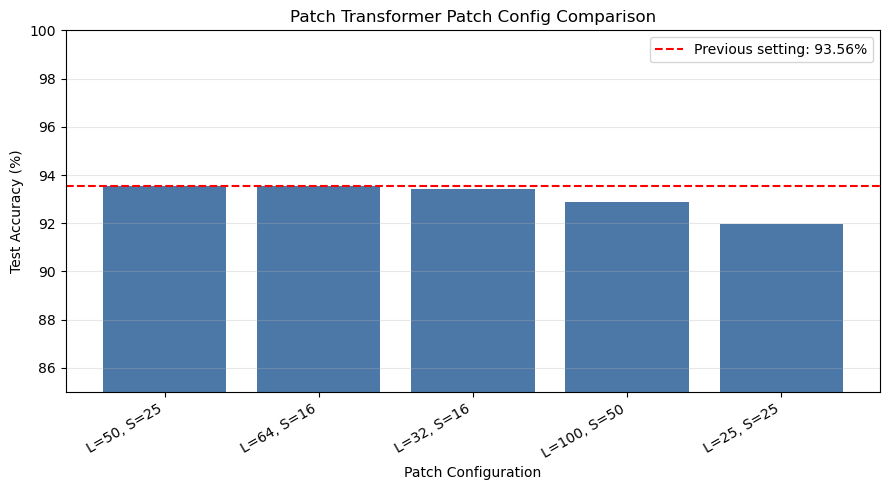

Best patch configuration:
patch_len            50.000000
stride               25.000000
num_patches          19.000000
best_epoch           16.000000
best_val_accuracy     0.923717
test_accuracy         0.935606
Name: 0, dtype: float64


In [28]:
def train_patch_transformer_config(patch_len, stride, max_epochs=50, patience=7, min_delta=0.0005):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    model = PatchTransformerClassifier(
        seq_len=X_deep.shape[1],
        patch_len=patch_len,
        stride=stride,
        embed_dim=64,
        num_heads=4,
        num_layers=2,
        ff_dim=128,
        dropout=0.1,
        num_classes=2,
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    best_val_acc = 0.0
    best_epoch = 0
    best_state = None
    epochs_without_improvement = 0

    for epoch in range(1, max_epochs + 1):
        model.train()

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()

        _, val_acc, _, _ = evaluate_torch_model(model, val_loader)

        if val_acc > best_val_acc + min_delta:
            best_val_acc = val_acc
            best_epoch = epoch
            best_state = {key: value.cpu().clone() for key, value in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            break

    model.load_state_dict(best_state)
    _, test_acc, y_true, y_pred = evaluate_torch_model(model, test_loader)
    num_patches = ((X_deep.shape[1] - patch_len) // stride) + 1

    return {
        'patch_len': patch_len,
        'stride': stride,
        'num_patches': num_patches,
        'best_epoch': best_epoch,
        'best_val_accuracy': best_val_acc,
        'test_accuracy': test_acc,
        'model': model,
        'y_true': y_true,
        'y_pred': y_pred,
    }

patch_configs = [
    {'patch_len': 25, 'stride': 25},
    {'patch_len': 32, 'stride': 16},
    {'patch_len': 50, 'stride': 25},
    {'patch_len': 64, 'stride': 16},
    {'patch_len': 100, 'stride': 50},
]

patch_tuning_results = []

for config in patch_configs:
    print(f"Running patch_len={config['patch_len']}, stride={config['stride']}...")
    result = train_patch_transformer_config(
        patch_len=config['patch_len'],
        stride=config['stride'],
        max_epochs=50,
        patience=7,
    )
    patch_tuning_results.append(result)
    print(
        f"  patches={result['num_patches']:2d} | "
        f"best_epoch={result['best_epoch']:2d} | "
        f"val={result['best_val_accuracy']*100:.2f}% | "
        f"test={result['test_accuracy']*100:.2f}%"
    )

patch_tuning_df = pd.DataFrame([
    {key: value for key, value in result.items() if key not in ['model', 'y_true', 'y_pred']}
    for result in patch_tuning_results
]).sort_values('test_accuracy', ascending=False).reset_index(drop=True)

display(patch_tuning_df.assign(
    best_val_accuracy=lambda df: (df['best_val_accuracy'] * 100).round(2),
    test_accuracy=lambda df: (df['test_accuracy'] * 100).round(2),))

best_patch_result = patch_tuning_results[int(patch_tuning_df.index[0])]
best_patch_row = patch_tuning_df.iloc[0]

plt.figure(figsize=(9, 5))
labels = [f"L={row.patch_len}, S={row.stride}" for row in patch_tuning_df.itertuples()]
plt.bar(labels, patch_tuning_df['test_accuracy'] * 100, color='#4C78A8')
plt.axhline(patch_test_acc * 100, color='red', linestyle='--', label=f'Previous setting: {patch_test_acc*100:.2f}%')
plt.title('Patch Transformer Patch Config Comparison')
plt.xlabel('Patch Configuration')
plt.ylabel('Test Accuracy (%)')
plt.ylim(85, 100)
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print('Best patch configuration:')
print(best_patch_row)

## Attention Map 시각화

CLS 토큰이 각 패치에 얼마나 집중하는지를 시각화한다. 정상/비정상 샘플에서 Attention 분포가 어떻게 다른지 비교하면, 모델이 실제로 어느 시간 구간을 고장 판단의 근거로 삼는지 간접적으로 확인할 수 있다.

- **Attention Map**: 마지막 Transformer 레이어에서 CLS 토큰이 각 패치에 부여한 가중치
- **파형**: 원본 시계열, 배경색이 짙을수록 해당 구간의 Attention이 높다는 의미

/tmp/ipykernel_13534/2247778783.py:53: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('YlOrRd')
/tmp/ipykernel_13534/2247778783.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


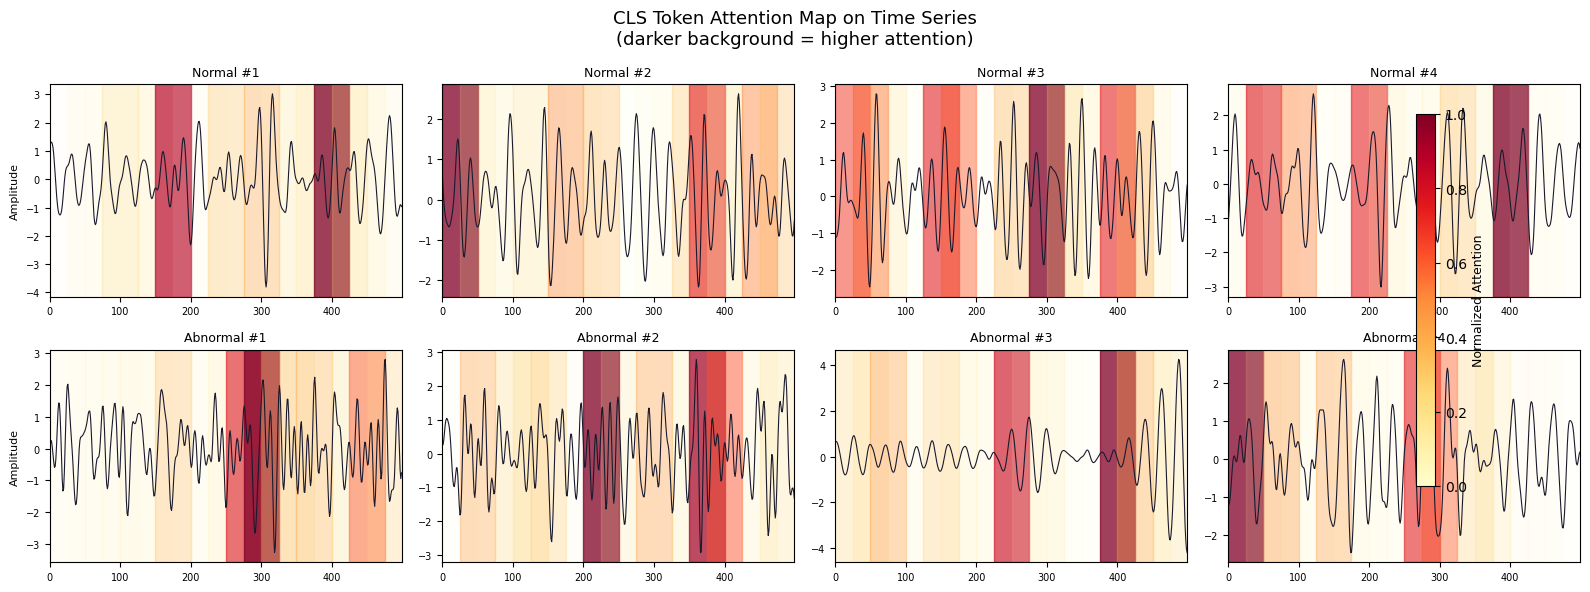

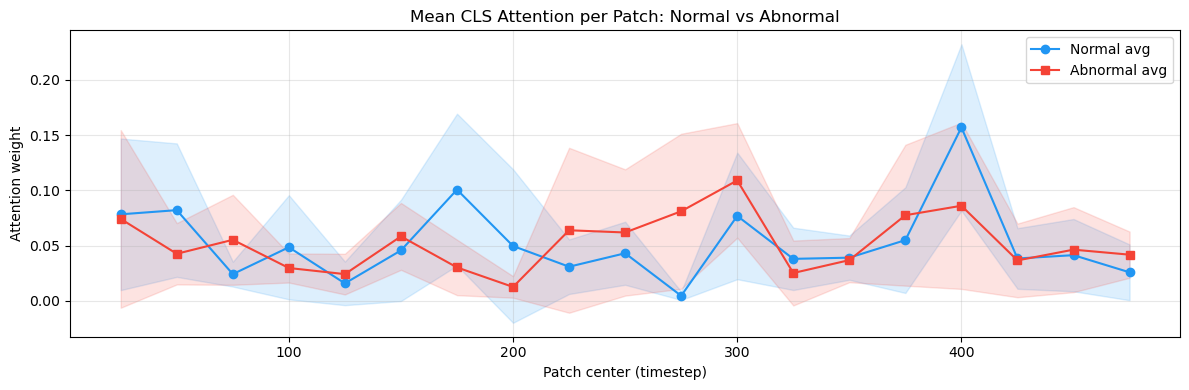

In [30]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# patch_len=50, stride=25 기준 최적 모델(patch_model) 사용
patch_len_vis = 50
stride_vis    = 25
num_patches_vis = ((X_deep.shape[1] - patch_len_vis) // stride_vis) + 1  # 19

last_layer = patch_model.encoder.layers[-1]

# PyTorch TransformerEncoderLayer는 내부적으로 need_weights=False로 호출하기 때문에
# hook에서 attention weight를 가져올 수 없다.
# 대신 마지막 레이어의 입력 텐서를 hook으로 캡처한 뒤,
# self_attn을 need_weights=True로 직접 재호출한다.
layer_input_cache = {}

def input_hook(module, input, output):
    layer_input_cache['src'] = input[0].detach()

def get_cls_attention(indices):
    X_sel = torch.tensor(X_test_deep[indices]).unsqueeze(1).to(device)
    hook_handle = last_layer.register_forward_hook(input_hook)
    patch_model.eval()
    with torch.no_grad():
        patch_model(X_sel)
    hook_handle.remove()

    src = layer_input_cache['src']  # (n, num_patches+1, embed_dim)
    with torch.no_grad():
        _, attn_weights = last_layer.self_attn(
            src, src, src,
            need_weights=True,
            average_attn_weights=True,
        )
    # attn_weights: (n, num_patches+1, num_patches+1)
    # CLS 행(0)에서 패치 열(1:) 추출
    cls_attn = attn_weights[:, 0, 1:].cpu().numpy()  # (n, num_patches)
    return cls_attn

# ── 정상/비정상 샘플 각 4개 선택 ─────────────────────────────────────────────
n_show = 4
normal_idx   = np.where(y_test_deep == 1)[0][:n_show]
abnormal_idx = np.where(y_test_deep == 0)[0][:n_show]

normal_attn   = get_cls_attention(normal_idx)
abnormal_attn = get_cls_attention(abnormal_idx)

# ── 패치 시작/끝 타임스텝 ─────────────────────────────────────────────────────
patch_starts = [i * stride_vis for i in range(num_patches_vis)]
patch_ends   = [s + patch_len_vis for s in patch_starts]

# ── 파형 + Attention 배경색 시각화 ───────────────────────────────────────────
cmap = cm.get_cmap('YlOrRd')

fig, axes = plt.subplots(2, n_show, figsize=(16, 6))
fig.suptitle('CLS Token Attention Map on Time Series\n(darker background = higher attention)', fontsize=13)

for row_idx, (label, idxs, attns) in enumerate([
    ('Normal',   normal_idx,   normal_attn),
    ('Abnormal', abnormal_idx, abnormal_attn),
]):
    for col in range(n_show):
        ax = axes[row_idx][col]
        raw  = X_test_deep[idxs[col]]
        attn = attns[col]
        attn_norm = (attn - attn.min()) / (attn.max() - attn.min() + 1e-8)

        for s, e, a in zip(patch_starts, patch_ends, attn_norm):
            ax.axvspan(s, e, alpha=float(a) * 0.7 + 0.05, color=cmap(float(a)), zorder=0)

        ax.plot(raw, color='#1a1a2e', linewidth=0.8, zorder=2)
        ax.set_title(f'{label} #{col+1}', fontsize=9)
        ax.set_xlim(0, 499)
        ax.tick_params(labelsize=7)
        if col == 0:
            ax.set_ylabel('Amplitude', fontsize=8)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=mcolors.Normalize(0, 1))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, orientation='vertical', fraction=0.015, pad=0.02)
cbar.set_label('Normalized Attention', fontsize=9)
plt.tight_layout()
plt.show()

# ── 패치별 평균 Attention 비교: 정상 vs 비정상 ───────────────────────────────
patch_x = [(s + e) / 2 for s, e in zip(patch_starts, patch_ends)]

fig2, ax2 = plt.subplots(figsize=(12, 4))
ax2.plot(patch_x, normal_attn.mean(axis=0),   marker='o', label='Normal avg',   color='#2196F3')
ax2.plot(patch_x, abnormal_attn.mean(axis=0), marker='s', label='Abnormal avg', color='#F44336')
ax2.fill_between(patch_x,
    normal_attn.mean(0) - normal_attn.std(0),
    normal_attn.mean(0) + normal_attn.std(0),
    alpha=0.15, color='#2196F3')
ax2.fill_between(patch_x,
    abnormal_attn.mean(0) - abnormal_attn.std(0),
    abnormal_attn.mean(0) + abnormal_attn.std(0),
    alpha=0.15, color='#F44336')
ax2.set_title('Mean CLS Attention per Patch: Normal vs Abnormal')
ax2.set_xlabel('Patch center (timestep)')
ax2.set_ylabel('Attention weight')
ax2.legend()
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()